# 28-Day Forecast V4 — 4-Model Comparison

Trains and compares **4 models** on the 28-day dataset (5 years, 1,437 SKUs, 28 event features, no lag).
Uses date-based 5-fold cross-validation to check for overfitting before final test evaluation.

| Model | Notes |
|-------|-------|
| **LightGBM** | Gradient boosting — fast, handles tabular data well |
| **XGBoost** | Gradient boosting — alternative implementation |
| **Random Forest** | Bagged decision trees — robust baseline |
| **Neural Network** | MLP regressor — 2 hidden layers (128, 64) |

**Target:** `aggregated_sales_28` — sum of daily sales over 28 days

**Metrics:** MAE, RMSE, SMAPE, BIAS

## 1) Imports & Paths

In [1]:
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_SEED = 42
ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / '28_Day_Dataset'

print('Data dir:', DATA_DIR)

Data dir: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\28_Day_Dataset


## 2) Load Data

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['date'])
val_df   = pd.read_csv(DATA_DIR / 'val.csv',   parse_dates=['date'])
test_df  = pd.read_csv(DATA_DIR / 'test.csv',  parse_dates=['date'])

tv_df = pd.concat([train_df, val_df]).sort_values('date').reset_index(drop=True)

print(f'Train : {len(train_df):,} rows | {train_df["date"].min().date()} to {train_df["date"].max().date()}')
print(f'Val   : {len(val_df):,}   rows | {val_df["date"].min().date()} to {val_df["date"].max().date()}')
print(f'Test  : {len(test_df):,}  rows | {test_df["date"].min().date()} to {test_df["date"].max().date()}')
print(f'TV    : {len(tv_df):,} rows (train+val for CV)')

Train : 68,976 rows | 2011-01-29 to 2014-09-06
Val   : 14,370   rows | 2014-10-04 to 2015-06-13
Test  : 15,807  rows | 2015-07-11 to 2016-04-16
TV    : 83,346 rows (train+val for CV)


## 3) Features & Target

In [3]:
TARGET   = 'aggregated_sales_28'
DROP     = [TARGET, 'item_id', 'date']
FEATURES = [c for c in train_df.columns if c not in DROP]

X_train = train_df[FEATURES];  y_train = train_df[TARGET]
X_val   = val_df[FEATURES];    y_val   = val_df[TARGET]
X_test  = test_df[FEATURES];   y_test  = test_df[TARGET]

print(f'Target   : {TARGET}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Target   : aggregated_sales_28
Features (31): ['is_month_end', 'aggregated_sell_price', 'snap_ca', 'event_christmas_28', 'event_easter_28', 'event_eid_al_fitr_28', 'event_eid_al_adha_28', 'event_fathers_day_28', 'event_halloween_28', 'event_mothers_day_28', 'event_newyear_28', 'event_orthodox_christmas_28', 'event_orthodox_easter_28', 'event_ramadan_starts_28', 'event_thanksgiving_28', 'event_valentines_day_28', 'event_superbowl_28', 'event_independence_day_28', 'event_memorial_day_28', 'event_labor_day_28', 'event_mlk_day_28', 'event_presidents_day_28', 'event_columbus_day_28', 'event_veterans_day_28', 'event_st_patricks_day_28', 'event_cinco_de_mayo_28', 'event_chanukah_28', 'event_lent_start_28', 'event_lent_week2_28', 'event_pesach_end_28', 'event_purim_end_28']


## 4) Metric Helpers & Pipeline Factory

In [4]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)))

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'MAE':   round(float(mean_absolute_error(y_true, y_pred)), 4),
        'RMSE':  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'SMAPE': round(smape(y_true, y_pred), 4),
        'BIAS':  round(float(np.mean(y_pred - y_true)), 4),
    }

def make_pipeline(model):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('model',  model),
    ])

print('Helpers ready.')

Helpers ready.


## 5) Define All 4 Models

In [5]:
MODELS = {
    'LightGBM': make_pipeline(LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_SEED, verbose=-1,
    )),
    'XGBoost': make_pipeline(XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='reg:squarederror', tree_method='hist',
        random_state=RANDOM_SEED, verbosity=0,
    )),
    'Random Forest': make_pipeline(RandomForestRegressor(
        n_estimators=200, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_SEED,
    )),
    'Neural Network': make_pipeline(MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.001,
        max_iter=300, early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_SEED,
    )),
}

print('Models defined:', list(MODELS.keys()))

Models defined: ['LightGBM', 'XGBoost', 'Random Forest', 'Neural Network']


## 6) Cross-Validation (date-based TimeSeriesSplit, 5 folds)

Splits on **unique dates** — all items in a given window always stay in the same fold.
**Test data is never touched here.**

In [6]:
def run_cv(df, pipeline, n_splits=5):
    dates = np.array(sorted(df['date'].unique()))
    tscv  = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(dates), 1):
        tr = df[df['date'].isin(set(dates[tr_idx]))]
        va = df[df['date'].isin(set(dates[va_idx]))]
        pipe = copy.deepcopy(pipeline)
        pipe.fit(tr[FEATURES], tr[TARGET])
        m = compute_metrics(va[TARGET].values, pipe.predict(va[FEATURES]))
        m['fold'] = fold
        folds.append(m)
        print(f'  fold {fold}: MAE={m["MAE"]:.4f}  SMAPE={m["SMAPE"]:.2f}%  BIAS={m["BIAS"]:.4f}')
    return folds


cv_results = {}
for name, pipeline in MODELS.items():
    print(f'\n--- CV: {name} ---')
    cv_results[name] = run_cv(tv_df, pipeline)

print('\nCV complete.')


--- CV: LightGBM ---


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

  fold 1: MAE=56.3720  SMAPE=125.76%  BIAS=-18.6264


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 2: MAE=52.5493  SMAPE=116.53%  BIAS=-3.4871


...

  fold 3: MAE=54.5690  SMAPE=107.60%  BIAS=-12.8924


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 4: MAE=53.7218  SMAPE=96.04%  BIAS=-7.3710


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 5: MAE=48.9312  SMAPE=85.66%  BIAS=-4.0405

--- CV: XGBoost ---
  fold 1: MAE=57.2545  SMAPE=126.18%  BIAS=-18.5492
  fold 2: MAE=52.7729  SMAPE=116.98%  BIAS=-4.0508
  fold 3: MAE=55.2373  SMAPE=107.99%  BIAS=-12.9378
  fold 4: MAE=53.5551  SMAPE=95.32%  BIAS=-7.9428
  fold 5: MAE=49.5477  SMAPE=86.48%  BIAS=-3.6827

--- CV: Random Forest ---
  fold 1: MAE=56.5828  SMAPE=127.22%  BIAS=-19.5030
  fold 2: MAE=51.8440  SMAPE=117.88%  BIAS=-4.5836
  fold 3: MAE=55.1040  SMAPE=109.98%  BIAS=-12.7808
  fold 4: MAE=54.2247  SMAPE=99.21%  BIAS=-8.3365
  fold 5: MAE=50.6562  SMAPE=91.29%  BIAS=-5.1367

--- CV: Neural Network ---
  fold 1: MAE=58.4228  SMAPE=122.73%  BIAS=-15.9688
  fold 2: MAE=55.9475  SMAPE=116.03%  BIAS=2.0554
  fold 3: MAE=59.2890  SMAPE=108.60%  BIAS=-2.8436
  fold 4: MAE=54.8642  SMAPE=95.49%  BIAS=-4.5667
  fold 5: MAE=50.2003  SMAPE=88.12%  BIAS=-1.6360

CV complete.


## 7) CV Summary Table

In [7]:
cv_summary_rows = []
for name, folds in cv_results.items():
    fd = pd.DataFrame(folds)
    cv_summary_rows.append({
        'model':          name,
        'CV_MAE_mean':   round(fd['MAE'].mean(),   4),
        'CV_MAE_std':    round(fd['MAE'].std(),    4),
        'CV_RMSE_mean':  round(fd['RMSE'].mean(),  4),
        'CV_SMAPE_mean': round(fd['SMAPE'].mean(), 4),
        'CV_SMAPE_std':  round(fd['SMAPE'].std(),  4),
        'CV_BIAS_mean':  round(fd['BIAS'].mean(),  4),
    })

cv_summary = pd.DataFrame(cv_summary_rows).sort_values('CV_MAE_mean').reset_index(drop=True)
print('=== Cross-Validation Summary (5 folds, sorted by mean MAE) ===')
print(cv_summary.to_string(index=False))

=== Cross-Validation Summary (5 folds, sorted by mean MAE) ===
         model  CV_MAE_mean  CV_MAE_std  CV_RMSE_mean  CV_SMAPE_mean  CV_SMAPE_std  CV_BIAS_mean
      LightGBM      53.2287      2.7771      127.1320       106.3167       15.9383       -9.2835
       XGBoost      53.6735      2.8773      127.9564       106.5903       16.0102       -9.4327
 Random Forest      53.6823      2.4117      127.7169       109.1164       14.3264      -10.0681
Neural Network      55.7448      3.5809      128.0068       106.1963       14.2941       -4.5919


## 8) Train on Full Train Set — Evaluate Val & Test

Each model trained on `train_df` only, evaluated on val and test separately.

In [8]:
trained = {}
final_rows = []

for name, pipeline in MODELS.items():
    print(f'Training {name}...')
    pipe = copy.deepcopy(pipeline)
    pipe.fit(X_train, y_train)
    trained[name] = pipe

    p_val  = pipe.predict(X_val)
    p_test = pipe.predict(X_test)

    cv_mae   = next(r['CV_MAE_mean']   for r in cv_summary_rows if r['model'] == name)
    cv_smape = next(r['CV_SMAPE_mean'] for r in cv_summary_rows if r['model'] == name)

    for split, y_true, y_pred in [('val', y_val, p_val), ('test', y_test, p_test)]:
        m = compute_metrics(y_true.values, y_pred)
        final_rows.append({'model': name, 'split': split,
                           'CV_MAE_mean': cv_mae, 'CV_SMAPE_mean': cv_smape, **m})

print('\nAll models trained.')

Training LightGBM...


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training XGBoost...
Training Random Forest...
Training Neural Network...

All models trained.


## 9) Full Comparison Table + Side-by-Side Bar Charts

=== TEST SET RESULTS (sorted by MAE) ===
         model     MAE    RMSE   SMAPE    BIAS
Neural Network 46.5394 97.9807 90.1446 -1.7367
      LightGBM 46.6012 98.9836 88.2573 -0.7381
       XGBoost 46.7163 98.6887 88.8849 -0.4417
 Random Forest 47.6941 99.2661 92.3005 -1.3797

=== VAL SET RESULTS (sorted by MAE) ===
         model     MAE     RMSE   SMAPE    BIAS
      LightGBM 49.1208 110.5152 85.8127 -4.6526
       XGBoost 49.7459 110.9597 86.6466 -4.1230
Neural Network 49.9395 110.8604 88.1914 -4.0583
 Random Forest 50.6685 111.9119 91.3267 -5.5774


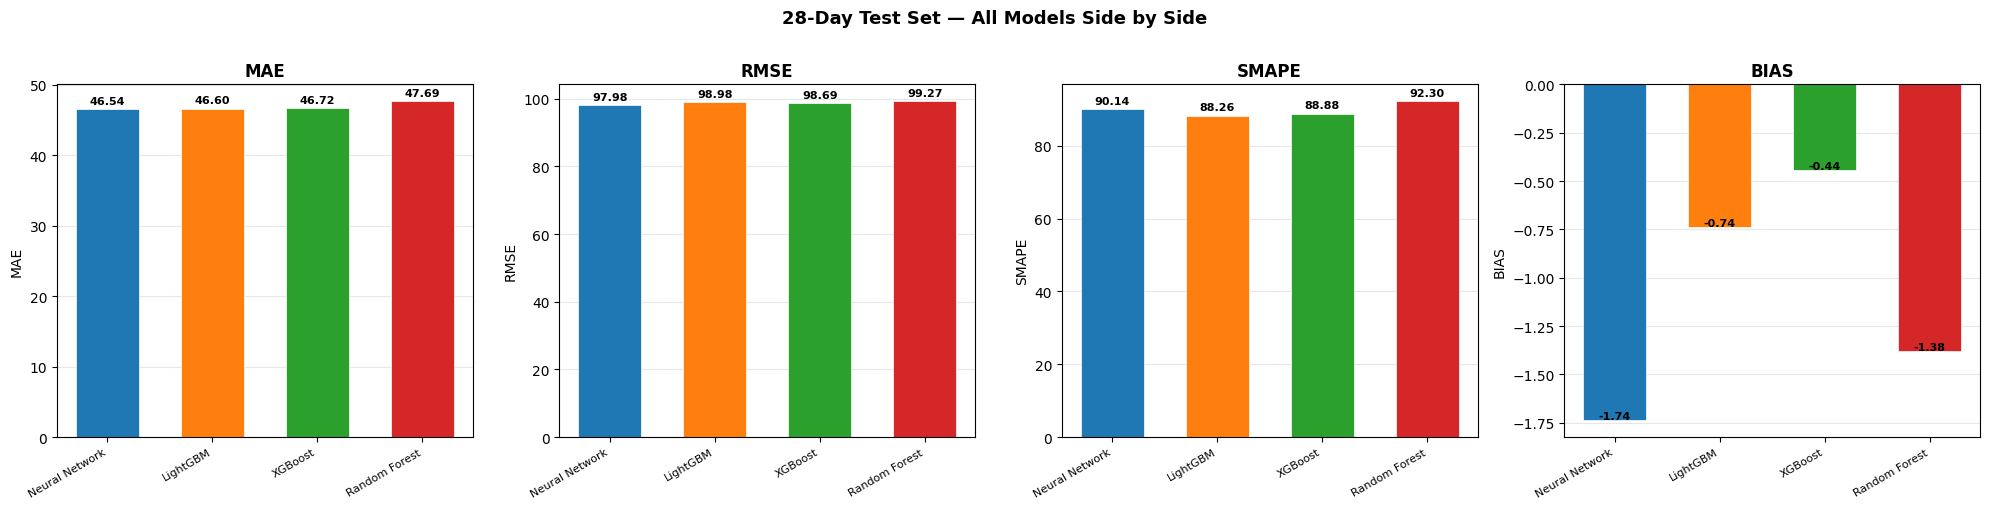

In [9]:
results_df = pd.DataFrame(final_rows)

print('=== TEST SET RESULTS (sorted by MAE) ===')
test_res = results_df[results_df['split'] == 'test'].sort_values('MAE')
print(test_res[['model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']].to_string(index=False))

print()
print('=== VAL SET RESULTS (sorted by MAE) ===')
val_res = results_df[results_df['split'] == 'val'].sort_values('MAE')
print(val_res[['model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']].to_string(index=False))

# ── Side-by-side bar charts ────────────────────────────────────────────────────
metrics   = ['MAE', 'RMSE', 'SMAPE', 'BIAS']
models    = test_res['model'].tolist()
colors    = plt.cm.tab10.colors[:len(models)]
x         = np.arange(len(models))
bar_width = 0.6

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
fig.suptitle('28-Day Test Set — All Models Side by Side', fontsize=13, fontweight='bold', y=1.01)

for ax, metric in zip(axes, metrics):
    values = test_res[metric].tolist()
    bars   = ax.bar(x, values, width=bar_width, color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 10) Overfitting Check — CV SMAPE vs Test SMAPE

Small gap = model generalises. Large positive gap = overfitting.

In [10]:
overfit = test_res[['model', 'CV_SMAPE_mean', 'SMAPE']].copy()
overfit['gap (test - CV)'] = (overfit['SMAPE'] - overfit['CV_SMAPE_mean']).round(4)
print('=== Overfitting Check (sorted by gap) ===')
print(overfit.sort_values('gap (test - CV)').to_string(index=False))

=== Overfitting Check (sorted by gap) ===
         model  CV_SMAPE_mean   SMAPE  gap (test - CV)
      LightGBM       106.3167 88.2573         -18.0594
       XGBoost       106.5903 88.8849         -17.7054
 Random Forest       109.1164 92.3005         -16.8159
Neural Network       106.1963 90.1446         -16.0517


## 11) Actual vs Predicted — Test Set (window average)

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


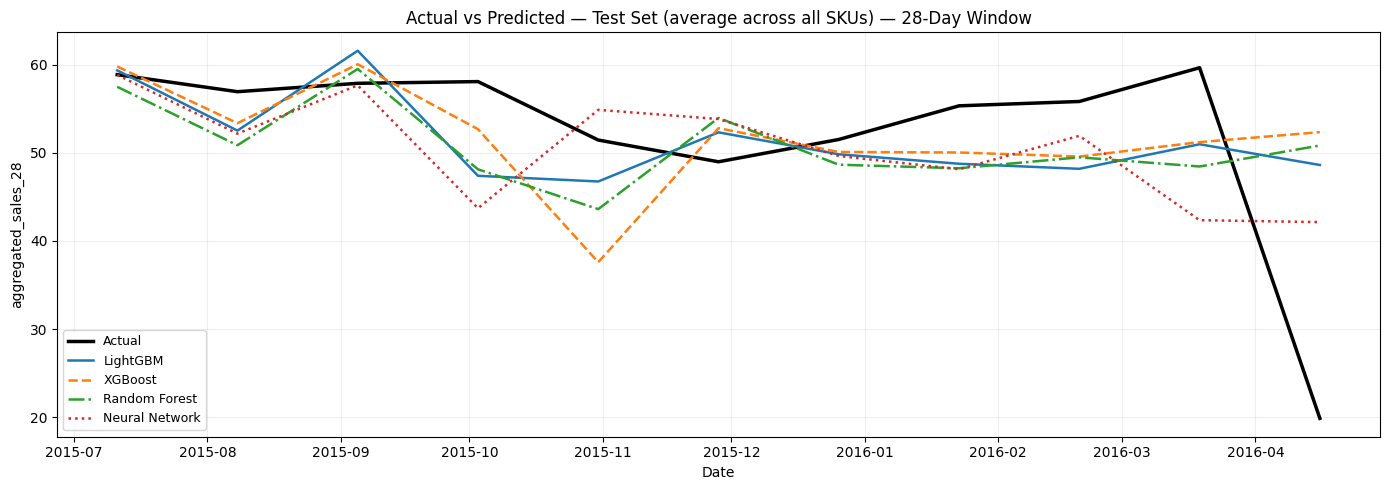

In [11]:
plot_df = test_df[['date']].copy()
plot_df['Actual'] = y_test.values
for name, pipe in trained.items():
    plot_df[name] = pipe.predict(X_test)

daily = plot_df.groupby('date', as_index=False).mean(numeric_only=True).sort_values('date')

styles = ['-', '--', '-.', ':']
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date'], daily['Actual'], label='Actual', color='black', linewidth=2.5)
for i, name in enumerate(trained):
    ax.plot(daily['date'], daily[name], label=name, linewidth=1.8, linestyle=styles[i % len(styles)])
ax.set_title('Actual vs Predicted — Test Set (average across all SKUs) — 28-Day Window')
ax.set_xlabel('Date')
ax.set_ylabel('aggregated_sales_28')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 12) Residual Distributions — Test Set

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


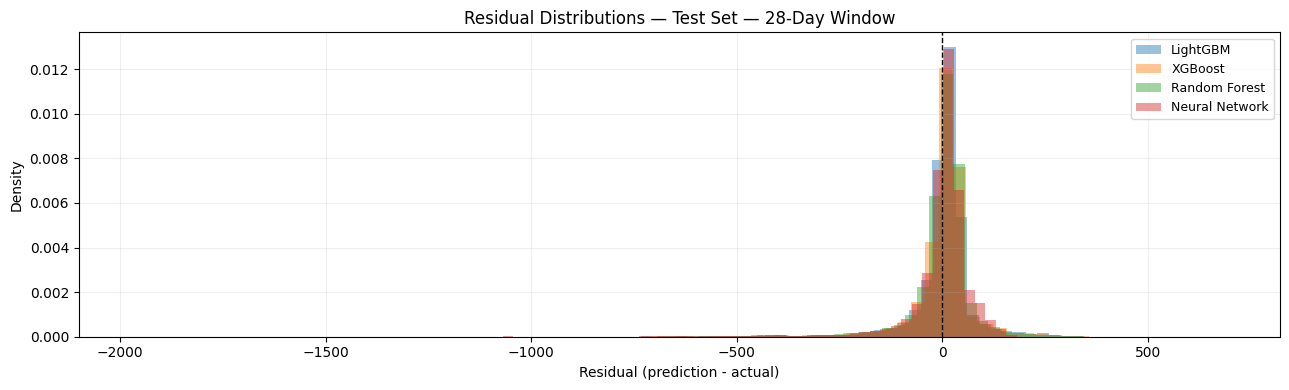

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
for name, pipe in trained.items():
    res = pipe.predict(X_test) - y_test.values
    ax.hist(res, bins=80, alpha=0.45, density=True, label=name)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Residual Distributions — Test Set — 28-Day Window')
ax.set_xlabel('Residual (prediction - actual)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 13) Feature Importance — Tree-Based Models

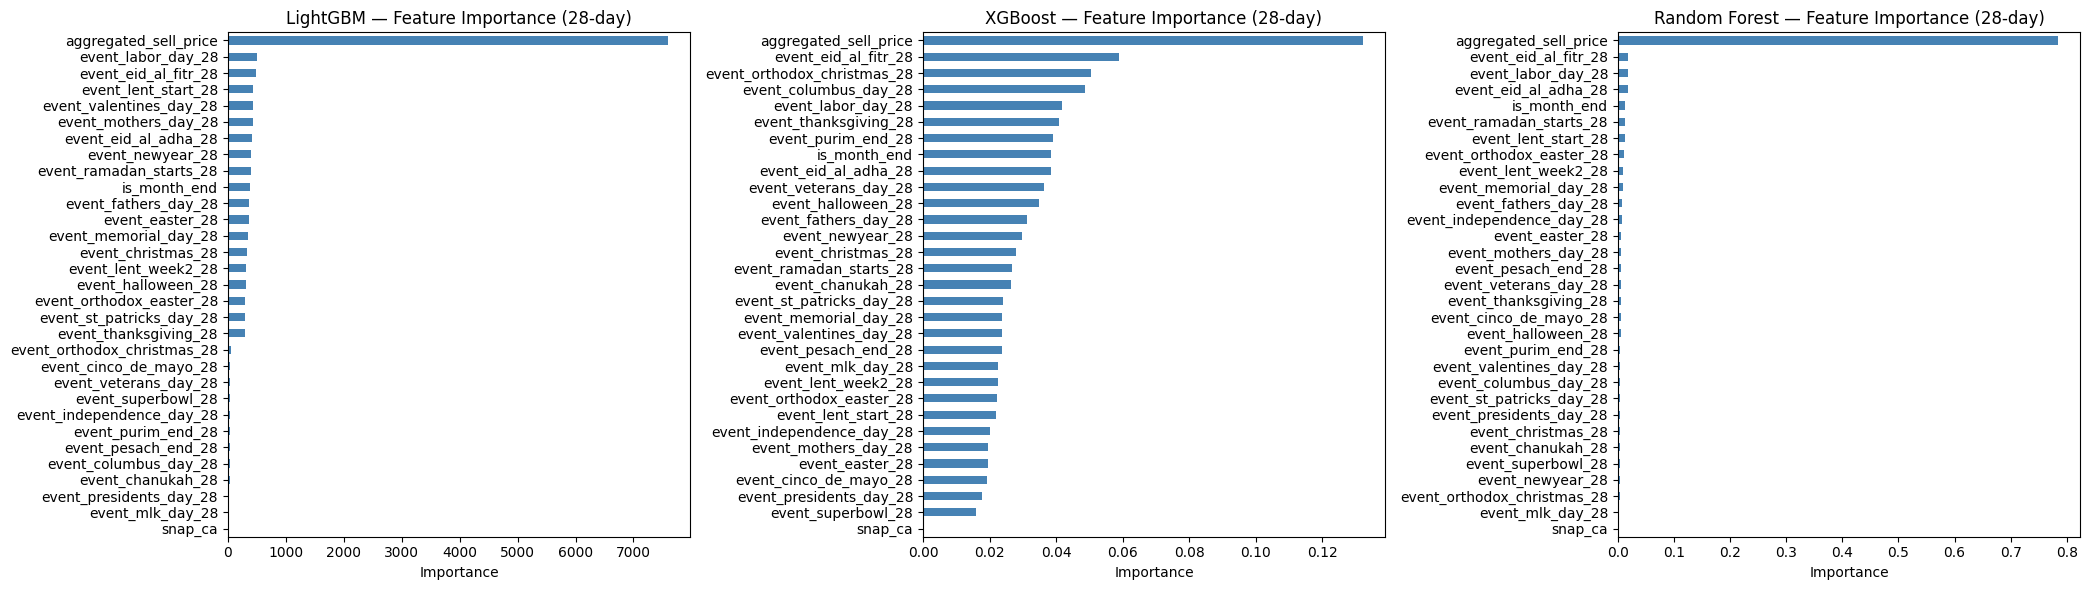

In [13]:
tree_models = {n: p for n, p in trained.items() if n in ('LightGBM', 'XGBoost', 'Random Forest')}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 6))
for ax, (name, pipe) in zip(axes, tree_models.items()):
    fi = pd.Series(
        pipe.named_steps['model'].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)
    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Feature Importance (28-day)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()